In [1]:
"""
Info:
top 10 najjacih kupaca kupuje od 70k - 15k itema
unique racuna (invoice #) ima oko 100 puta manje nego redaka u tablici
Datumi:Oldest Invoice Date: 2018-01-01 00:00:00
Youngest Invoice Date: 2020-06-30 00:00:00
Oldest Order Date: 1993-04-29 00:00:00 - OVA DVA SU EXTRA SUS
Youngest Order Date: 9999-12-31 00:00:00  - IMA 1000 + o vakvih datuma


"""

'\nInfo:\ntop 10 najjacih kupaca kupuje od 70k - 15k itema\nunique racuna (invoice #) ima oko 100 puta manje nego redaka u tablici\nDatumi:Oldest Invoice Date: 2018-01-01 00:00:00\nYoungest Invoice Date: 2020-06-30 00:00:00\nOldest Order Date: 1993-04-29 00:00:00 - OVA DVA SU EXTRA SUS\nYoungest Order Date: 9999-12-31 00:00:00  - IMA 1000 + o vakvih datuma\n\n\n'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score as sklearn_silhouette_score
from customer_vectorization_functions import function1
from segmentation_functions import my_adjusted_kmeans, merge_kmeans, hierarchical_stratification

In [3]:
#ucčitavanje podataka
df = pd.read_csv(
    "LUMEN_DS.csv",
    sep="|",
    quotechar='"',
    encoding="utf-16",)

/var/folders/qb/1gz7kjgd1nncs_s1n4yd3st00000gn/T/ipykernel_3887/869548833.py:2: DtypeWarning: Columns (0: Sales Channel - Grouping, 1: Invoice Line #) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1294962 entries, 0 to 1294961
Data columns (total 33 columns):
 #   Column                               Non-Null Count    Dtype  
---  ------                               --------------    -----  
 0   Manufacturing Region                 1254453 non-null  str    
 1   Manufacturing Location Code          1255003 non-null  str    
 2   Intercompany                         1294962 non-null  str    
 3   CustomerID                           1294962 non-null  int64  
 4   Customer industry                    1294962 non-null  str    
 5   Customer Region                      1294859 non-null  str    
 6   Customer First Invoice Date          1294962 non-null  str    
 7   Top Customer Group                   1294962 non-null  str    
 8   Item Code                            1294907 non-null  str    
 9   Product family                       1294962 non-null  str    
 10  Product group                        1126302 non-null  str    
 11  Price las

In [37]:
df["# of unique products on a quote"].unique()

array([  1.,   3.,  14.,   6.,   2.,   5.,   4., 399.,  43.,   7.,  10.,
        23.,  16.,  12.,  50.,  17.,  18.,  44., 202.,  11., 141.,  22.,
        21.,   8.,  13.,  24.,  47.,  19.,  37.,  25.,  15.,   9.,  35.,
        55.,  26.,  54.,  31.,  29.,  48.,  28.,  30.,  40.,  34.,  20.,
        63.,  95.,  42.,  27.,  53.,  33.,  32.,  38.,  39.,   0., 114.,
       177.,  41.,  59., 374., 164.,  79., 100.,  49.,  94.,  65.,  45.,
        60.,  84., 259.,  97.,  52.,  57.,  56.,  nan,  93.,  36.,  76.,
        74.,  64.,  78.,  69.,  89.,  81.])

In [10]:
df[df["Invoice #"] == 16927662]["Order Date"]

588634     2018-02-27
1294961    2018-02-27
Name: Order Date, dtype: str

In [46]:
df["Invoice Date"]

0          2019-08-06
1          2019-11-26
2          2019-09-24
3          2020-03-20
4          2020-03-20
              ...    
1294957    2020-04-15
1294958    2019-03-19
1294959    2019-08-12
1294960    2019-08-13
1294961    2018-03-02
Name: Invoice Date, Length: 1294962, dtype: str

In [ ]:
#oldest and youngest InvoiceDate who has format "yyyy-mm-dd" in string format if not in format "yyyy-mm-dd" convert it to that format and then find oldest and youngest date
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%Y-%m-%d", errors='coerce')
oldest_date = df["Order Date"].min()
youngest_date = df["Order Date"].max()
#second youngest date
second_youngest_date = df["Order Date"].nlargest(2).iloc[-1]
print("Oldest Order Date:", oldest_date)
print("Youngest Order Date:", youngest_date)
print("Second Youngest Order Date:", second_youngest_date)

Oldest Order Date: 1993-04-29 00:00:00
Youngest Order Date: 9999-12-31 00:00:00
Second Youngest Order Date: 9999-12-31 00:00:00


In [55]:
#top 10 newest dates in Order Date
top_10_newest_dates = df["Order Date"].nlargest(10000)
print("Top 10 Newest Order Dates:")
print(top_10_newest_dates)

Top 10 Newest Order Dates:
119      9999-12-31
120      9999-12-31
2153     9999-12-31
2154     9999-12-31
2155     9999-12-31
            ...    
142265   9999-12-31
142266   9999-12-31
142267   9999-12-31
142268   9999-12-31
142269   9999-12-31
Name: Order Date, Length: 10000, dtype: datetime64[us]


In [44]:
df.head()

,Manufacturing Region,Manufacturing Location Code,Intercompany,CustomerID,Customer industry,Customer Region,Customer First Invoice Date,Top Customer Group,Item Code,Product family,...,Invoiced qty (shipped),Ordered qty,Invoiced price,Invoiced price (TX),Cost of part,Material cost of part,Labor cost of part,Overhead cost of part,GM%,# of unique products on a quote
0,North America,N7,YES,224224,IC000,Asia,2009-06-26 00:00:00,OTHER,054501,PF002,...,499.0,499.0,0.39,0.39,0.4173,0.390,0.0,0.0,-0.070000,1.0
1,North America,N7,NO,230494,IC012,North America,2007-08-08 00:00:00,OTHER,034903,PF002,...,1000.0,1000.0,0.14,0.14,0.0257,0.024,0.0,0.0,0.816429,3.0
2,Asia,N13,YES,235861,IC000,North America,2008-02-07 00:00:00,OTHER,057280,PF002,...,3.0,3.0,0.00,0.00,0.0000,0.000,0.0,0.0,NaN,14.0
3,Asia,N13,NO,223839,IC000,Asia,2003-09-08 00:00:00,OTHER,309146,PF002,...,2000.0,5000.0,0.20,0.20,0.0000,0.000,0.0,0.0,1.000000,1.0
4,Asia,N13,NO,223839,IC000,Asia,2003-09-08 00:00:00,OTHER,309146,PF002,...,1230.0,5000.0,0.20,0.20,0.0000,0.000,0.0,0.0,1.000000,1.0


In [22]:
"""
for i in df.columns:
    if df[i].dtype == "object":
        df[i][df[i].isnull()] = "Unknown"

a,c = np.unique(df["Invoice Line #"], return_counts=True)
sorted_indices = np.argsort(c)[::-1]
sorted_a = a[sorted_indices]
sorted_c = c[sorted_indices]
print(sorted_c[:10])
print(sorted_a[:10])
"""

'\nfor i in df.columns:\n    if df[i].dtype == "object":\n        df[i][df[i].isnull()] = "Unknown"\n\na,c = np.unique(df["Invoice Line #"], return_counts=True)\nsorted_indices = np.argsort(c)[::-1]\nsorted_a = a[sorted_indices]\nsorted_c = c[sorted_indices]\nprint(sorted_c[:10])\nprint(sorted_a[:10])\n'

In [ ]:
#

[ 19244  18161 224597 294128  18163  24039  23981  25172  19118  21141]
[70230 65059 40748 17866 17723 17377 16751 16498 15115 14995]


'\nplt.xlabel("CustomerID")\nplt.ylabel("Frequency")\nplt.title("Top 10 CustomerID Frequency")\nplt.xticks(rotation=45)\nplt.show()'

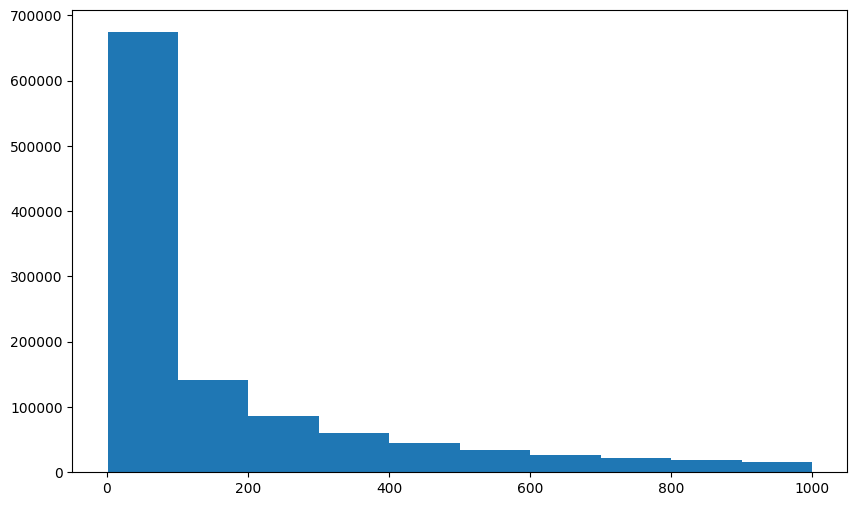

In [40]:
#frquency plot of unique values in "CustomerID" column
a,c = np.unique(df["CustomerID"], return_counts=True)
sorted_indices = np.argsort(c)[::-1]
sorted_a = a[sorted_indices]
sorted_c = c[sorted_indices]
plt.figure(figsize=(10, 6))
print(sorted_a[:10])
print(sorted_c[:10])
plt.hist(range(1, 1001), weights=sorted_c[:1000])
"""
plt.xlabel("CustomerID")
plt.ylabel("Frequency")
plt.title("Top 10 CustomerID Frequency")
plt.xticks(rotation=45)
plt.show()"""

In [15]:
df["Invoice Line #"]

0          18645771
1          18670413
2          18655474
3          18688647
4          18688639
             ...   
1294957     6486527
1294958     9880134
1294959    18647035
1294960    18646308
1294961    18532756
Name: Invoice Line #, Length: 1294962, dtype: object

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1294962 entries, 0 to 1294961
Data columns (total 33 columns):
 #   Column                               Non-Null Count    Dtype  
---  ------                               --------------    -----  
 0   Manufacturing Region                 1254453 non-null  str    
 1   Manufacturing Location Code          1255003 non-null  str    
 2   Intercompany                         1294962 non-null  str    
 3   CustomerID                           1294962 non-null  int64  
 4   Customer industry                    1294962 non-null  str    
 5   Customer Region                      1294859 non-null  str    
 6   Customer First Invoice Date          1294962 non-null  str    
 7   Top Customer Group                   1294962 non-null  str    
 8   Item Code                            1294907 non-null  str    
 9   Product family                       1294962 non-null  str    
 10  Product group                        1126302 non-null  str    
 11  Price las

In [61]:
#all values that apear in Make vs Buy column
print(df["Make vs Buy"].unique())

<StringArray>
[                 'BUY',         'MANUFACTURED',                    nan,
          'BUY - LOCAL',            'PURCHASED',       'FINISHED GOODS',
      'PURCHASED (RAW)',         'RAW MATERIAL',       'BUY - IMPORTED',
 'BUY - INTERPLNT TRNS',                 'b306', 'BUY - CUST. SUPPLIED',
                 'A125',                 'A102']
Length: 14, dtype: str


In [3]:
#ovdje gledamo koliko svaki covjek/kompanija je napravio narudžbi i po toj mjeri micemo outliere, njih je 1%, njih posebno hendlat

n_orders_per_customer = df.groupby('CustomerID').size().reset_index(name='n_orders')
high_volume_threshold = n_orders_per_customer['n_orders'].quantile(0.99)  # Top 1%
high_volume_customers = n_orders_per_customer[
    n_orders_per_customer['n_orders'] > high_volume_threshold
]['CustomerID'].tolist()

print(f"High-volume customers (>{high_volume_threshold:.0f} orders): {len(high_volume_customers)} ({len(high_volume_customers)/len(n_orders_per_customer)*100:.1f}%)")

# Separate them
df_high_volume = df[df['CustomerID'].isin(high_volume_customers)]
df_regular = df[~df['CustomerID'].isin(high_volume_customers)]

High-volume customers (>1680 orders): 123 (1.0%)


In [4]:
data_points_imputed_df, data_points_imputed = function1(df_regular)       

c:\Users\lovro\Desktop\lumen\customer_vectorization_functions.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Order Date_temp'] = pd.to_datetime(df['Order Date'], errors='coerce')


Total unique customers: 12091
NaN counts before imputation:
0    1576
1    1576
2       0
3       5
4      74
5       0
6    5010
7    4806
8    4633
9    4263
dtype: int64

NaN counts after imputation:
0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
dtype: int64


In [5]:
import numpy as np

def metrics(data_points, labels):
    k = labels.max() + 1
    
    # Compute centroids
    centroids = np.vstack([
        data_points[labels == i].mean(axis=0)
        for i in range(k)
    ])
    
    # Silhouette
    silhouette = sklearn_silhouette_score(data_points, labels)
    
    # Mean distance to assigned centroid
    mean_centroid_distance = np.mean(
        np.linalg.norm(data_points - centroids[labels], axis=1)
    )
    
    return silhouette, mean_centroid_distance

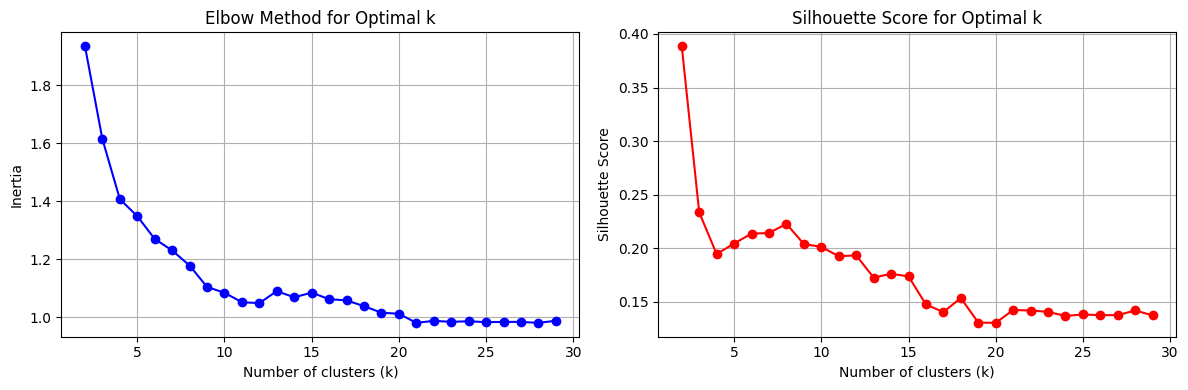

k=2: Silhouette Score = 0.3886
k=3: Silhouette Score = 0.2334
k=4: Silhouette Score = 0.1945
k=5: Silhouette Score = 0.2043
k=6: Silhouette Score = 0.2136
k=7: Silhouette Score = 0.2141
k=8: Silhouette Score = 0.2227
k=9: Silhouette Score = 0.2039
k=10: Silhouette Score = 0.2012
k=11: Silhouette Score = 0.1925
k=12: Silhouette Score = 0.1933
k=13: Silhouette Score = 0.1725
k=14: Silhouette Score = 0.1760
k=15: Silhouette Score = 0.1736
k=16: Silhouette Score = 0.1474
k=17: Silhouette Score = 0.1403
k=18: Silhouette Score = 0.1534
k=19: Silhouette Score = 0.1305
k=20: Silhouette Score = 0.1302
k=21: Silhouette Score = 0.1423
k=22: Silhouette Score = 0.1418
k=23: Silhouette Score = 0.1405
k=24: Silhouette Score = 0.1367
k=25: Silhouette Score = 0.1381
k=26: Silhouette Score = 0.1375
k=27: Silhouette Score = 0.1375
k=28: Silhouette Score = 0.1418
k=29: Silhouette Score = 0.1372


In [6]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

"""
 tu se računa klasični k means i silouhette score(to nisam ziher kaj je to je chat dao) 
 za raličit broj clustera da se odredi optimalni k
"""

column_names = ['days_diff', 'last_order', 'n_orders', 'avg_price', 
                'avg_ordered_qty', 'avg_delivered_qty',
                'corr_price_ordered', 'corr_price_delivered', 
                'corr_qty', 'gm']


# 2. Scale the data (crucial for k-means!)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_points_imputed_df)

# 3. Find optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 30)

for k in K_range:
    """
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    silhouette_score, inertia = metrics(data_scaled, kmeans.labels_)
    """
    #ovo je adjusted k means koji uvijek daje clustere koji imaju barem 100 članova
    #final_labels = my_adjusted_kmeans(data_scaled,k, min_size=100)
    #final_labels = merge_kmeans(data_scaled, k, min_size=100)
    final_labels = hierarchical_stratification(data_scaled, k, min_size=100)
    
    silhouette_score, inertia = metrics(data_scaled, final_labels)
    
    inertias.append(inertia)
    silhouette_scores.append(silhouette_score)

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow method plot
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True)

# Silhouette score plot
axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score for Optimal k')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Print silhouette scores
for k, score in zip(K_range, silhouette_scores):
    print(f"k={k}: Silhouette Score = {score:.4f}")

# 4. Choose optimal k (let's say based on silhouette score)


In [7]:
data_scaled.shape

(12091, 10)


Optimal number of clusters: 12
(12091, 10)

=== Cluster Analysis ===

Cluster sizes:
0      187
1      173
2     1119
3      250
4      363
5      147
6     1621
7      146
8      623
9     1169
10     501
11     318
12     220
13     825
14     330
15    2238
16     321
17     245
18     151
19     243
20     757
21     144
Name: Cluster, dtype: int64

Cluster means (scaled back to original units):
           days_diff   last_order     n_orders    avg_price  avg_ordered_qty  \
Cluster                                                                        
0         463.438503  6857.582888    60.657754    74.839468     1.336656e+06   
1         859.878613  6758.479769   581.156069   130.328713     2.176076e+04   
2         627.863271  6808.772118    25.459339   181.778429     2.230802e+03   
3         349.056000  6960.704000    19.492000   386.069786     7.617936e+03   
4         749.278237  6757.388430    33.614325   376.686727     3.125497e+03   
5         947.040816  6685.857143  1

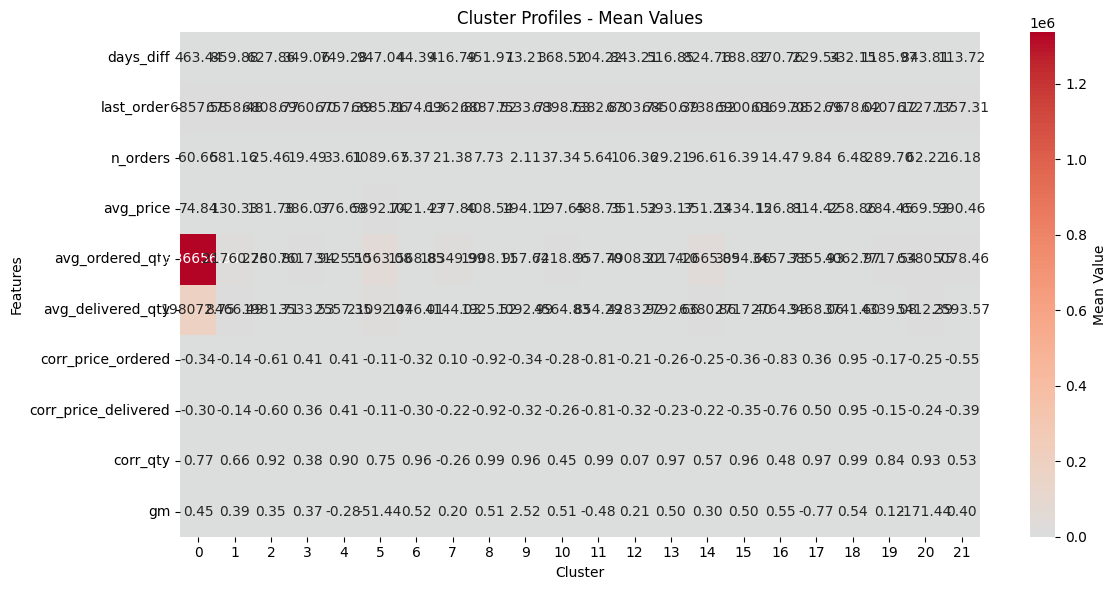

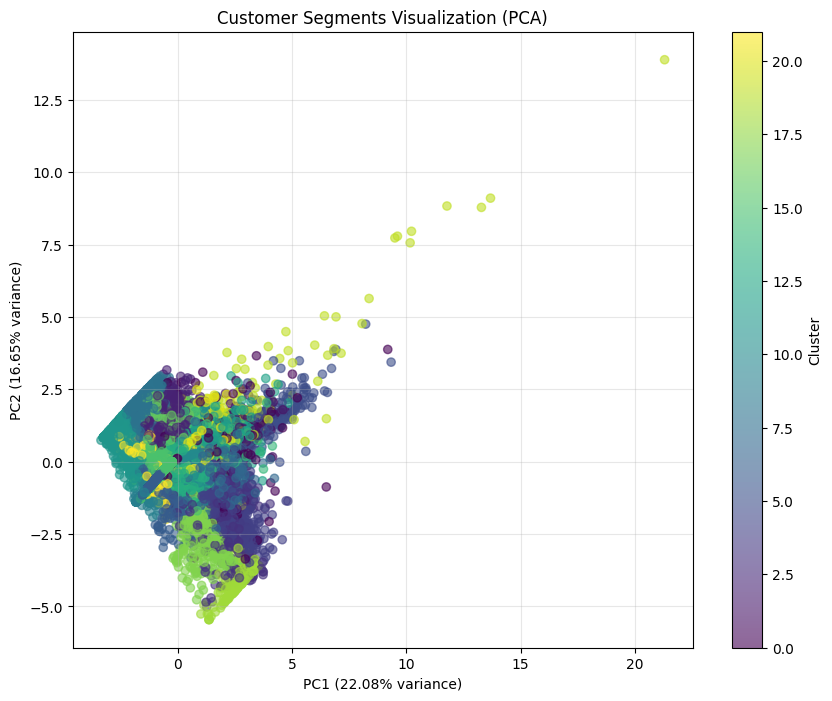

NameError: name 'final_kmeans' is not defined

In [ ]:
# odabrao sam 11 tu sad dalje ide neka analiza i vizualizacija
optimal_k = 12
print(f"\nOptimal number of clusters: {optimal_k}")

print(data_scaled.shape)

# ovo je klasicni kmeans
"""
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(data_scaled)
"""
#ovo je adjusted k means koji uvijek daje clustere koji imaju barem 100 članova
#cluster_labels =  my_adjusted_kmeans(data_scaled, optimal_k, min_size=100)
#cluster_labels = merge_kmeans(data_scaled, optimal_k, min_size=100)
cluster_labels = hierarchical_stratification(data_scaled, optimal_k, min_size=100)

# Add cluster labels to your dataframe
labeled_data_points_imputed_df = data_points_imputed_df.copy()
labeled_data_points_imputed_df['Cluster'] = cluster_labels

# 6. Analyze cluster characteristics
print("\n=== Cluster Analysis ===")
print("\nCluster sizes:")
print(labeled_data_points_imputed_df['Cluster'].value_counts().sort_index())

# Calculate mean values for each cluster
cluster_means = labeled_data_points_imputed_df.groupby('Cluster').mean()
print("\nCluster means (scaled back to original units):")
print(cluster_means)

# 7. Visualize cluster profiles
# Create a heatmap of cluster characteristics
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means.T, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', cbar_kws={'label': 'Mean Value'})
plt.title('Cluster Profiles - Mean Values')
plt.ylabel('Features')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

# 8. Visualize clusters using PCA for 2D visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(data_pca[:, 0], data_pca[:, 1], 
                     c=cluster_labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Customer Segments Visualization (PCA)')
plt.grid(True, alpha=0.3)
plt.show()

# 9. Analyze feature importance for clustering
# Look at cluster centers
cluster_centers = scaler.inverse_transform(final_kmeans.cluster_centers_)
cluster_centers_df = pd.DataFrame(cluster_centers, columns=column_names)
print("\nCluster Centers (original units):")
print(cluster_centers_df)


# 11. Optional: Characterize each cluster
print("\n=== Cluster Characterization ===")
for cluster in range(optimal_k):
    print(f"\nCluster {cluster} (n={sum(cluster_labels==cluster)} customers):")
    cluster_data = labeled_data_points_imputed_df[labeled_data_points_imputed_df['Cluster'] == cluster]
    
    # Print key characteristics
    print(f"  Average days between orders: {cluster_data['days_diff'].mean():.1f}")
    print(f"  Average order value: ${cluster_data['avg_price'].mean():.2f}")
    print(f"  Average order quantity: {cluster_data['avg_ordered_qty'].mean():.1f}")
    print(f"  Average GM%: {cluster_data['gm'].mean():.1f}%")
    print(f"  Price-Order correlation: {cluster_data['corr_price_ordered'].mean():.3f}")

In [ ]:
"""
postoje invoice price 0 narudzbe, onda gm% bude nan i nemogu korelaciju gledati
ponekad je inovice price 0, a product cost nije, mogao bih onda gm% postaviti na -max
order qty i deliver qty se razlikuju
invoice dateovi neki su invalidni


nisam zadovoljan sve skupa jer postoje klasteri s po jednom osobom, možda su to ovi izdvojeni iz skupine na slici
"""

'\npostoje invoice price 0 narudzbe, onda gm% bude nan i nemogu korelaciju gledati\nponekad je inovice price 0, a product cost nije, mogao bih onda gm% postaviti na -max\norder qty i deliver qty se razlikuju\ninvoice dateovi neki su invalidni\n\n\nnisam zadovoljan sve skupa jer postoje klasteri s po jednom osobom, možda su to ovi izdvojeni iz skupine na slici\n'